# Unblinding plot

This is after fixing the 2pt differences between ours and public (sompzv.05).

map3 is also update with the proper scale cut at 3pcf level

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
import sys
sys.path.append('../python')
import utils
import threepoint
%matplotlib inline

In [3]:
# Public chains
# This hass error in nz (sompz v0.4)
blind = False
public_old_chain      = utils.read_cosmosis_mcmc_des_chain(
    '../public_chains/chain_1x2pt_lcdm_SR_maglim.txt', to_mcsamples=True, blind=blind)
public_old_chain_opt  = utils.read_cosmosis_mcmc_des_chain(
    '../public_chains/chain_1x2pt_lcdm_SR_maglim_opt.txt', to_mcsamples=True, blind=blind)
public_old_chain_wcdm = utils.read_cosmosis_mcmc_des_chain(
    '../public_chains/chain_1x2pt_wcdm_SR_maglim.txt', to_mcsamples=True, blind=blind)


Removed no burn in
Removed no burn in
Removed no burn in


In [4]:
# DES Y3 unblind
blind = False
desy3_2pt = utils.read_cosmosis_mcmc_des_chain(
    '../output/unblind-metacal-796sims-february-Percival-2ptfix/des-y3-2pt-unblind-metacal-simcov.txt', to_mcsamples=True, blind=blind)
desy3_23pt= utils.read_cosmosis_mcmc_des_chain(
    '../output/unblind-metacal-796sims-february-Percival-2ptfix-3pcfsc/des-y3-2pt-map3-all-unblind-metacal.txt', to_mcsamples=True, blind=blind)
desy3_3pt = utils.read_cosmosis_mcmc_des_chain(
    '../output/unblind-metacal-796sims-february-Percival-2ptfix-3pcfsc/des-y3-map3-all-unblind-metacal.txt', to_mcsamples=True, blind=blind)


Removed no burn in
Removed no burn in
Removed no burn in


In [5]:
# DES Y3 blind
blind = False
desy3_b_2pt = utils.read_cosmosis_mcmc_des_chain(
    '../output/blind-metacal-796sims-february/des-y3-2pt-blind-metacal-simcov.txt', to_mcsamples=True, blind=blind)
desy3_b_23pt= utils.read_cosmosis_mcmc_des_chain(
    '../output/blind-metacal-796sims-february/des-y3-2pt-map3-all-blind-metacal.txt', to_mcsamples=True, blind=blind)
desy3_b_3pt = utils.read_cosmosis_mcmc_des_chain(
    '../output/blind-metacal-796sims-february/des-y3-map3-all-blind-metacal.txt', to_mcsamples=True, blind=blind)


Removed no burn in
Removed no burn in
Removed no burn in


In [6]:
# # Check convergence by looking at the weight
# plt.plot(desy3_2pt.weights[:-800])
# plt.plot(desy3_23pt.weights[:-800])
# plt.plot(desy3_3pt.weights[:-800])
# plt.show()

<Figure size 600x600 with 0 Axes>

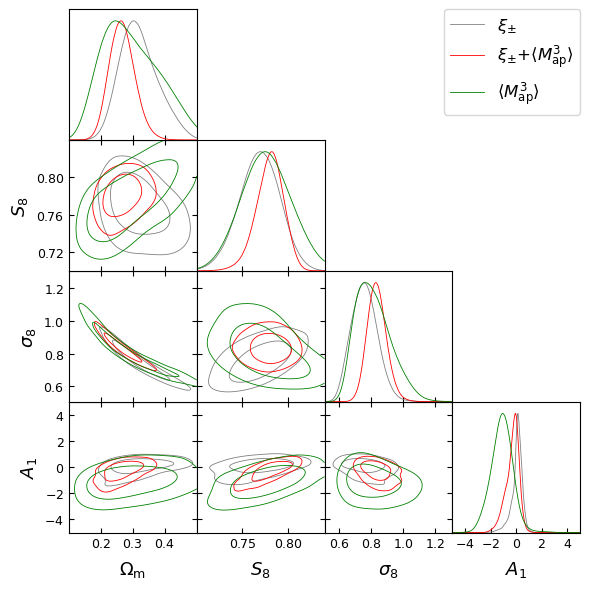

In [7]:
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.settings.lab_fontsize = 17
g.settings.axes_fontsize = 13
g.settings.legend_fontsize = 16
g.settings.figure_legend_frame = True
g.triangle_plot([desy3_2pt, 
                 desy3_23pt, 
                 desy3_3pt], 
                ['om', 's8', 'sig8', 'a1'], 
                filled=False, 
                legend_labels=[r'$\xi_{\pm}$',
                               r'$\xi_{\pm}$+$\langle M_{\rm ap}^3\rangle$', 
                               r'$\langle M_{\rm ap}^3\rangle$'], 
                legend_loc='upper right', 
                contour_colors=['gray', 'red', 'green', 'k', 'b'])#, 
                # markers={'om':0.26, 's8':0.782, 'sig8':0.84, 'a1':0})
plt.show()

In [8]:
#fom improvement
fom_2pt = utils.FoM_from_samples_names(desy3_2pt, ['om', 's8'])
fom_23pt = utils.FoM_from_samples_names(desy3_23pt, ['om', 's8'])

print(fom_2pt, fom_23pt)
print((fom_23pt/fom_2pt-1)*100)

818.3995370589045 1728.5159984990241
111.20686415718413


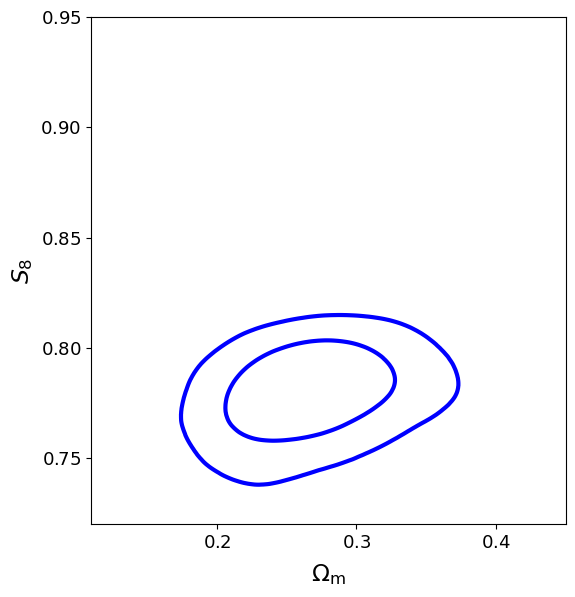

In [9]:
# This is to overplot our constraint on the figure from other papers
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.settings.lab_fontsize = 17
g.settings.axes_fontsize = 13
g.settings.legend_fontsize = 16
g.settings.figure_legend_frame = True

g.plot_2d([desy3_23pt], 'om', 's8', colors=['blue'], lws=[3])
ax = g.get_axes()
ax.set_ylim(0.72, 0.95)
ax.set_xlim(0.11, 0.45)
plt.show()

### Using optimized scale cut for 2pt

In [10]:
# DES Y3 unblind
blind = False
desy3_2pt_opt2 = utils.read_cosmosis_mcmc_des_chain(
    '../output/unblind-metacal-796sims-february-Percival-2ptfix-3pcfsc/des-y3-2pt-unblind-metacal-simcov-opt2pt.txt', to_mcsamples=True, blind=blind)
desy3_23pt_opt2= utils.read_cosmosis_mcmc_des_chain(
    '../output/unblind-metacal-796sims-february-Percival-2ptfix-3pcfsc/des-y3-2pt-map3-all-unblind-metacal-opt2pt.txt', to_mcsamples=True, blind=blind)


Removed no burn in
Removed no burn in


<Figure size 600x600 with 0 Axes>

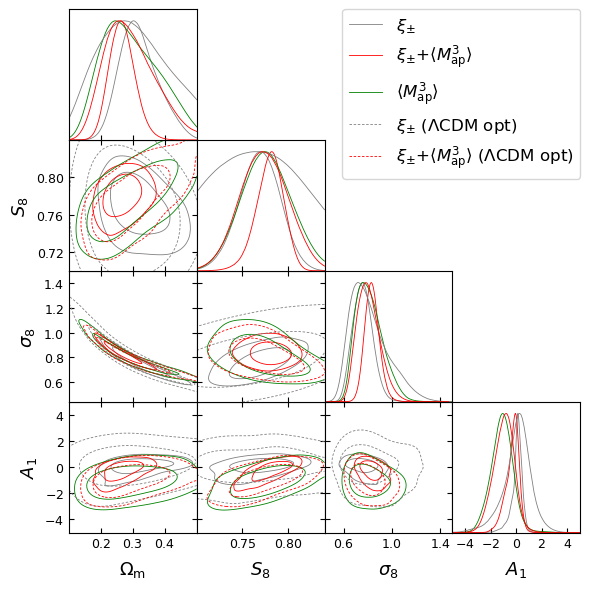

In [13]:
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.settings.lab_fontsize = 17
g.settings.axes_fontsize = 13
g.settings.legend_fontsize = 16
g.settings.figure_legend_frame = True
g.triangle_plot([desy3_2pt, 
                 desy3_23pt, 
                 desy3_3pt, 
                 desy3_2pt_opt2, 
                 desy3_23pt_opt2], 
                ['om', 's8', 'sig8', 'a1'], 
                filled=False, 
                legend_labels=[r'$\xi_{\pm}$',
                               r'$\xi_{\pm}$+$\langle M_{\rm ap}^3\rangle$', 
                               r'$\langle M_{\rm ap}^3\rangle$',
                               r'$\xi_{\pm}$ ($\Lambda$CDM opt)',
                               r'$\xi_{\pm}$+$\langle M_{\rm ap}^3\rangle$ ($\Lambda$CDM opt)'], 
                legend_loc='upper right', 
                contour_colors=['gray', 'red', 'green', 'gray', 'red'],
                ls=['-','-','-','--','--'],)
                # markers={'om':0.26, 's8':0.782, 'sig8':0.84, 'a1':0})
plt.show()

<Figure size 600x450 with 0 Axes>

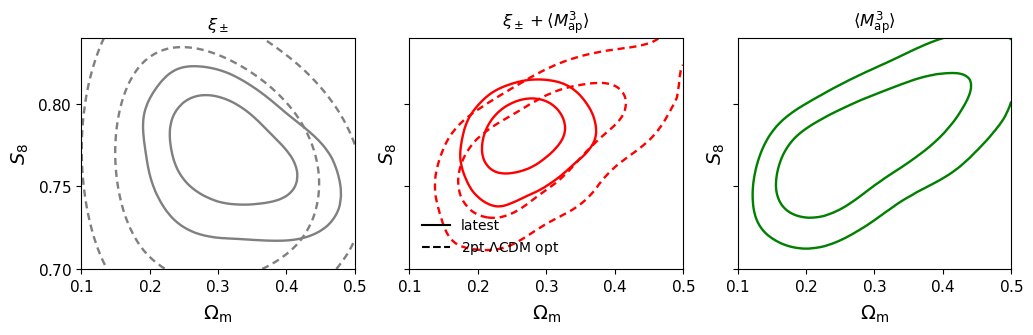

In [11]:
g = plots.get_single_plotter()
fig, axes = plt.subplots(1,3,figsize=(12,3), sharex=True, sharey=True)
g.plot_2d([desy3_2pt , desy3_2pt_opt2] , 'om', 's8', ax=axes[0], colors=['gray']*2 , ls=['-', '--'])
g.plot_2d([desy3_23pt, desy3_23pt_opt2], 'om', 's8', ax=axes[1], colors=['red']*2  , ls=['-', '--'])
g.plot_2d([desy3_3pt ] , 'om', 's8', ax=axes[2], colors=['green']*2, ls=['-', '--'])
axes[0].set_title(r'$\xi_\pm$')
axes[1].set_title(r'$\xi_\pm + \langle M_{\rm ap}^3\rangle$')
axes[2].set_title(r'$\langle M_{\rm ap}^3\rangle$')
# legend
axes[1].plot(np.nan, color='k', ls='-' , label='latest')
axes[1].plot(np.nan, color='k', ls='--', label=r'2pt $\Lambda$CDM opt')
axes[1].legend(loc='lower left', frameon=False)
plt.show()

In [8]:
moped1 = np.loadtxt('../data/moped/moped-moped-compress-2pt.txt')
moped2 = np.loadtxt('../data/moped/moped-moped-compress-2pt-opt2pt.txt')

In [9]:
moped1.shape, moped2.shape

((227, 16), (273, 16))

## Check the difference due to catalog update (sompz v04 -> v05)

In [20]:
# DES Y3 unblind
blind = False
desy3_2pt_v04 = utils.read_cosmosis_mcmc_des_chain(
    '../output/unblind-metacal-796sims-february-Percival-2ptfix-3pcfsc-sompzv04/des-y3-2pt-unblind-metacal-simcov.txt', to_mcsamples=True, blind=blind)
desy3_23pt_v04= utils.read_cosmosis_mcmc_des_chain(
    '../output/unblind-metacal-796sims-february-Percival-2ptfix-3pcfsc-sompzv04/des-y3-2pt-map3-all-unblind-metacal.txt', to_mcsamples=True, blind=blind)
desy3_3pt_v04 = utils.read_cosmosis_mcmc_des_chain(
    '../output/unblind-metacal-796sims-february-Percival-2ptfix-3pcfsc-sompzv04/des-y3-map3-all-unblind-metacal.txt', to_mcsamples=True, blind=blind)

Removed no burn in
Removed no burn in
Removed no burn in


<Figure size 600x600 with 0 Axes>

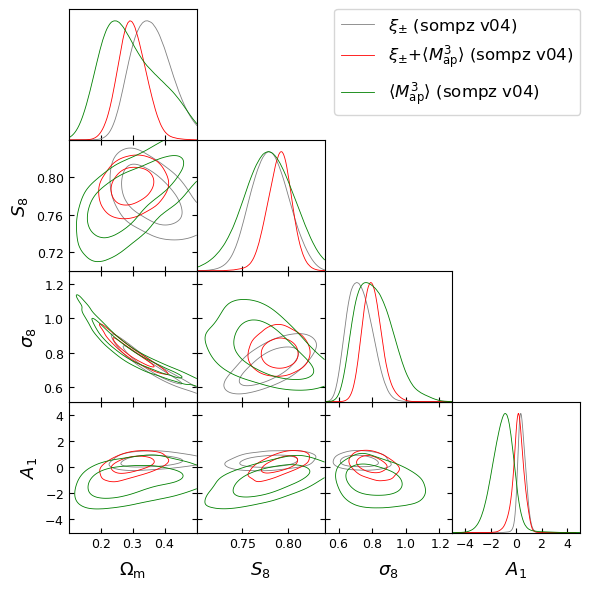

In [21]:
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.settings.lab_fontsize = 17
g.settings.axes_fontsize = 13
g.settings.legend_fontsize = 16
g.settings.figure_legend_frame = True
g.triangle_plot([desy3_2pt_v04, 
                 desy3_23pt_v04, 
                 desy3_3pt_v04], 
                ['om', 's8', 'sig8', 'a1'], 
                filled=False, 
                legend_labels=[r'$\xi_{\pm}$ (sompz v04)',
                               r'$\xi_{\pm}$+$\langle M_{\rm ap}^3\rangle$ (sompz v04)', 
                               r'$\langle M_{\rm ap}^3\rangle$ (sompz v04)'], 
                legend_loc='upper right', 
                contour_colors=['gray', 'red', 'green', 'k', 'b'])#, 
                # markers={'om':0.26, 's8':0.782, 'sig8':0.84, 'a1':0})
plt.show()

<Figure size 600x450 with 0 Axes>

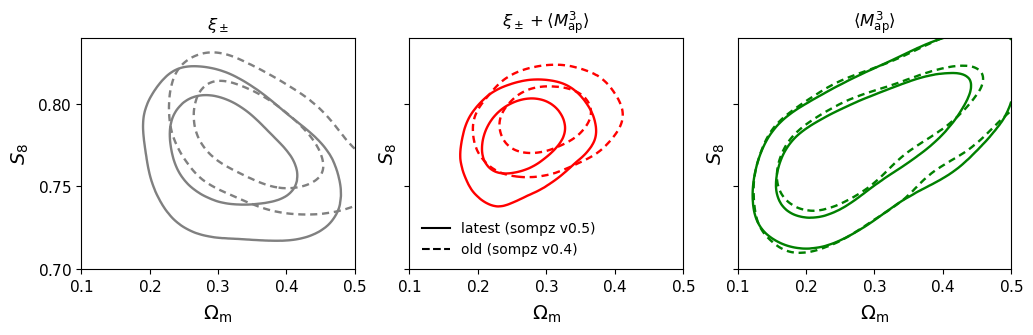

In [34]:
g = plots.get_single_plotter()
fig, axes = plt.subplots(1,3,figsize=(12,3), sharex=True, sharey=True)
g.plot_2d([desy3_2pt , desy3_2pt_v04] , 'om', 's8', ax=axes[0], colors=['gray']*2 , ls=['-', '--'])
g.plot_2d([desy3_23pt, desy3_23pt_v04], 'om', 's8', ax=axes[1], colors=['red']*2  , ls=['-', '--'])
g.plot_2d([desy3_3pt , desy3_3pt_v04] , 'om', 's8', ax=axes[2], colors=['green']*2, ls=['-', '--'])
axes[0].set_title(r'$\xi_\pm$')
axes[1].set_title(r'$\xi_\pm + \langle M_{\rm ap}^3\rangle$')
axes[2].set_title(r'$\langle M_{\rm ap}^3\rangle$')
# legend
axes[1].plot(np.nan, color='k', ls='-' , label='latest (sompz v0.5)')
axes[1].plot(np.nan, color='k', ls='--', label='old (sompz v0.4)')
axes[1].legend(loc='lower left', frameon=False)
plt.show()

## Comparison to Blinded one

<Figure size 600x600 with 0 Axes>

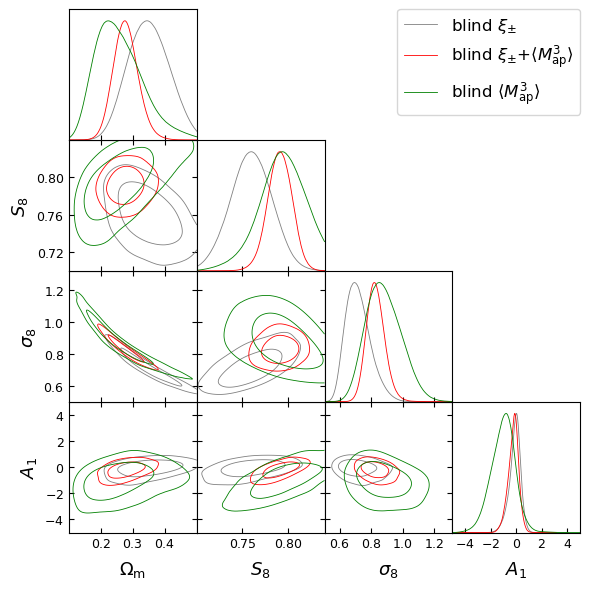

In [18]:
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.settings.lab_fontsize = 17
g.settings.axes_fontsize = 13
g.settings.legend_fontsize = 16
g.settings.figure_legend_frame = True
g.triangle_plot([desy3_b_2pt, 
                 desy3_b_23pt, 
                 desy3_b_3pt], 
                ['om', 's8', 'sig8', 'a1'], 
                filled=False, 
                legend_labels=[r'blind $\xi_{\pm}$',
                               r'blind $\xi_{\pm}$+$\langle M_{\rm ap}^3\rangle$', 
                               r'blind $\langle M_{\rm ap}^3\rangle$'], 
                legend_loc='upper right', 
                contour_colors=['gray', 'red', 'green', 'gray', 'red', 'green'],
                contour_ls=['-']*3+['--']*3)
                # markers={'om':0.26, 's8':0.782, 'sig8':0.84, 'a1':0})
plt.show()

## Comparison to Planck 2018

In [9]:
planck = utils.load_TTTEEElowE()

Removed no burn in


<Figure size 600x600 with 0 Axes>

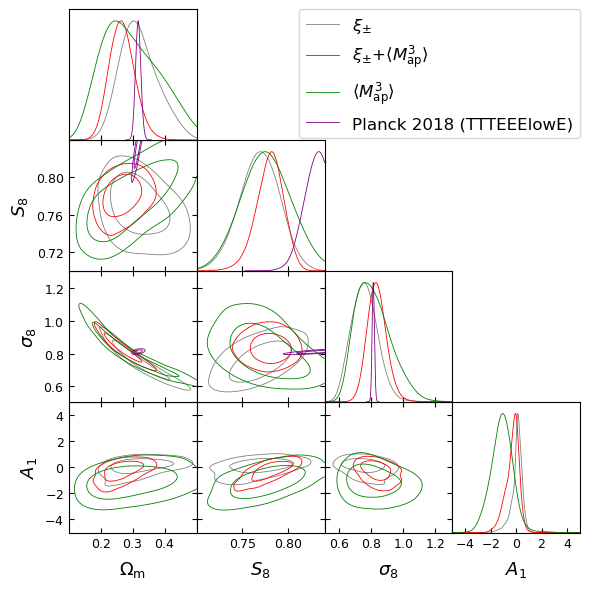

In [10]:
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.settings.lab_fontsize = 17
g.settings.axes_fontsize = 13
g.settings.legend_fontsize = 16
g.settings.figure_legend_frame = True
g.triangle_plot([desy3_2pt, 
                 desy3_23pt, 
                 desy3_3pt, 
                 planck], 
                ['om', 's8', 'sig8', 'a1'], 
                filled=False, 
                legend_labels=[r'$\xi_{\pm}$',
                               r'$\xi_{\pm}$+$\langle M_{\rm ap}^3\rangle$', 
                               r'$\langle M_{\rm ap}^3\rangle$', 
                               'Planck 2018 (TTTEEElowE)'], 
                legend_loc='upper right', 
                contour_colors=['gray', 'red', 'green', 'purple'])#, 
                # markers={'om':0.26, 's8':0.782, 'sig8':0.84, 'a1':0})
plt.show()